# Linear Model Training on Neurosoft Minipigs 2026

Minimal example: load a single session, extract fixed-length windows using
torch_brain's `SequentialFixedWindowSampler`, and train a logistic regression
on the **on_vs_off** binary classification task (intrasession split).

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

from auditorydecoding.datasets.neurosoft_minipigs_2026.NeurosoftMinipgs2026 import (
    NeurosoftMinipigs2026,
)
from auditorydecoding.features import FFTFeatures, MeanFeatures, StdFeatures, FlattenFeatures, IdentityFeatures
from auditorydecoding.windowing import extract_windows

In [3]:
DATA_ROOT = "../data/processed"
RECORDING_ID = "sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered"

WINDOW_LENGTH = 0.5  # seconds
FOLD_NUM = 0
SPLIT_TYPE = "intrasession-causal"
TASK_TYPE = "on_vs_off"
BALANCE_CLASSES = False

## Load the data and preprocess it

In [4]:
dataset = NeurosoftMinipigs2026(
    root=DATA_ROOT,
    recording_ids=[RECORDING_ID],
    fold_num=FOLD_NUM,
    split_type=SPLIT_TYPE,
    task_type=TASK_TYPE,
)

print(f"Recording IDs: {dataset.recording_ids}")

for split in ("train", "valid", "test"):
    intervals = dataset.get_sampling_intervals(split=split)
    for rid, iv in intervals.items():
        n = len(iv.start)
        dur = sum(iv.end - iv.start)
        print(f"  {split:>5s}: {n:4d} intervals, {dur:7.1f}s total")

Recording IDs: ['sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered']


ValueError: Invalid split_type 'intrasession-causal'.

## Get windows and feature matrix

In [ ]:
feature_extractor = IdentityFeatures()
# feature_extractor = FFTFeatures()

In [ ]:
X_train, y_train = extract_windows(dataset, "train", WINDOW_LENGTH, feature_extractor=feature_extractor)
X_valid, y_valid = extract_windows(dataset, "valid", WINDOW_LENGTH, feature_extractor=feature_extractor)
X_test, y_test = extract_windows(dataset, "test", WINDOW_LENGTH, feature_extractor=feature_extractor)

le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc = le.transform(y_test)

for name, X, y in [
    ("train", X_train, y_train),
    ("valid", X_valid, y_valid),
    ("test", X_test, y_test),
]:
    unique, counts = np.unique(y, return_counts=True)
    dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, counts))
    print(f"{name:>5s}  X={X.shape}  y={y.shape}  classes={{ {dist} }}")

train  X=(1804, 1001, 24)  y=(1804,)  classes={ off: 1132, on: 672 }
valid  X=(452, 1001, 24)  y=(452,)  classes={ off: 284, on: 168 }
 test  X=(1128, 1001, 24)  y=(1128,)  classes={ off: 708, on: 420 }


In [ ]:
X_train

array([[-2.62452060e-05, -6.82459098e-05,  1.11234178e-05, ...,
        -2.50695123e-04, -7.42319823e-05, -9.48325667e-06],
       [-1.70899268e-05,  6.14538888e-05, -1.67238913e-05, ...,
        -1.23145448e-03,  2.90834813e-04,  2.16346980e-04],
       [ 2.02941331e-05, -1.59798705e-04,  9.16135902e-05, ...,
        -2.04537256e-04,  5.69936990e-05, -5.56411260e-05],
       ...,
       [ 9.88101093e-05,  1.49576911e-04,  1.26505707e-04, ...,
        -1.04061393e-04, -6.24220298e-05, -4.93490638e-05],
       [-1.21679545e-04, -3.29549401e-04, -8.90248413e-05, ...,
        -1.16268432e-04,  8.82586190e-05,  2.18061401e-04],
       [-3.80531844e-06, -2.09401784e-05, -3.40931626e-05, ...,
         2.33495894e-05, -6.34593847e-06, -2.79867439e-05]],
      shape=(1804, 24024))

Feature matrix shapes:  train (1804, 24024)  valid (452, 24024)  test (1128, 24024)


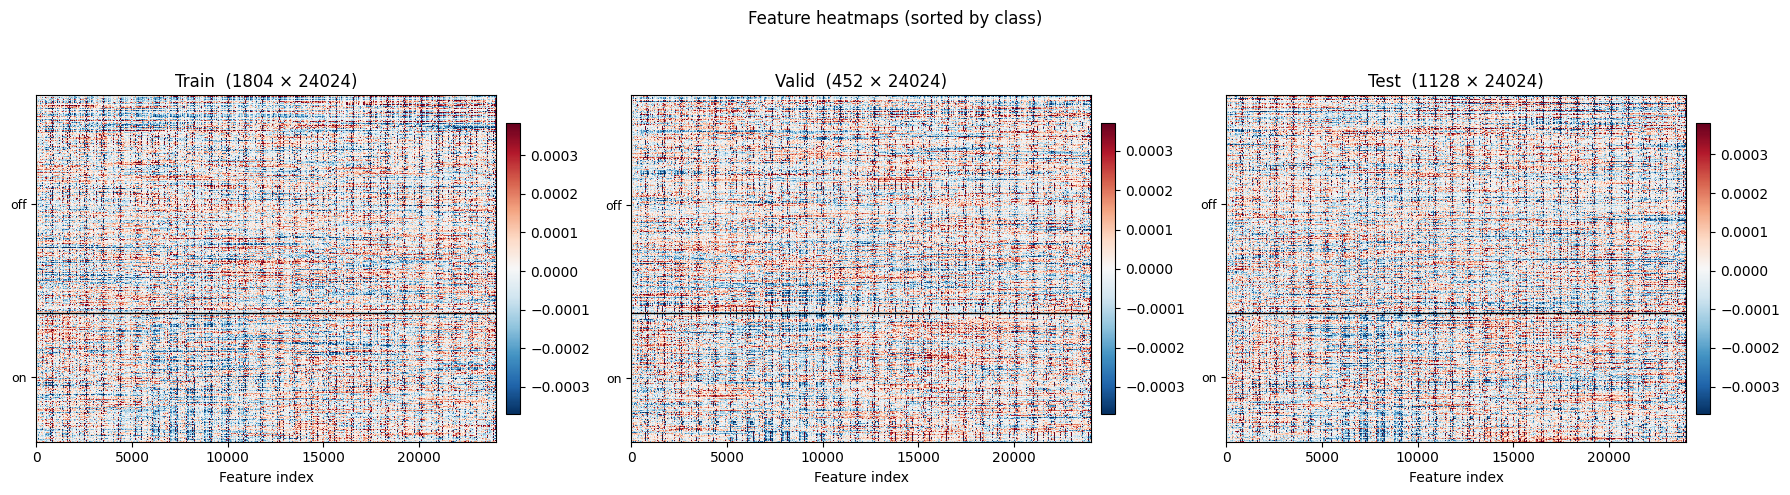

In [ ]:
print(f"Feature matrix shapes:  train {X_train.shape}  valid {X_valid.shape}  test {X_test.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X, y_enc, title in [
    (axes[0], X_train, y_train_enc, "Train"),
    (axes[1], X_valid, y_valid_enc, "Valid"),
    (axes[2], X_test, y_test_enc, "Test"),
]:
    order = np.argsort(y_enc)
    im = ax.imshow(
        X[order],
        aspect="auto",
        interpolation="none",
        cmap="RdBu_r",
        vmin=np.percentile(X, 2),
        vmax=np.percentile(X, 98),
    )

    boundaries = np.searchsorted(y_enc[order], np.arange(len(le.classes_)))
    for b in boundaries[1:]:
        ax.axhline(b - 0.5, color="k", linewidth=1)

    label_positions = [
        (boundaries[i] + (boundaries[i + 1] if i + 1 < len(boundaries) else len(y_enc))) / 2
        for i in range(len(boundaries))
    ]
    ax.set_yticks(label_positions)
    ax.set_yticklabels(le.classes_, fontsize=9)

    ax.set_xlabel("Feature index")
    ax.set_title(f"{title}  ({X.shape[0]} × {X.shape[1]})")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

fig.suptitle("Feature heatmaps (sorted by class)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Balance the classes

In [ ]:
if BALANCE_CLASSES:
    rng = np.random.default_rng(42)
    classes, counts = np.unique(y_train_enc, return_counts=True)
    min_count = counts.min()

    balanced_idx = np.concatenate([
        rng.choice(np.where(y_train_enc == c)[0], size=min_count, replace=False)
        for c in classes
    ])
    balanced_idx.sort()
    X_train, y_train, y_train_enc = (
        X_train[balanced_idx],
        y_train[balanced_idx],
        y_train_enc[balanced_idx],
    )

    for name, X, y in [
        ("train (balanced)", X_train, y_train),
        ("valid", X_valid, y_valid),
        ("test", X_test, y_test),
    ]:
        unique, cnt = np.unique(y, return_counts=True)
        dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, cnt))
        print(f"{name:>20s}  X={X.shape}  classes={{ {dist} }}")

## PCA

(0.0, 10801.384354599651)

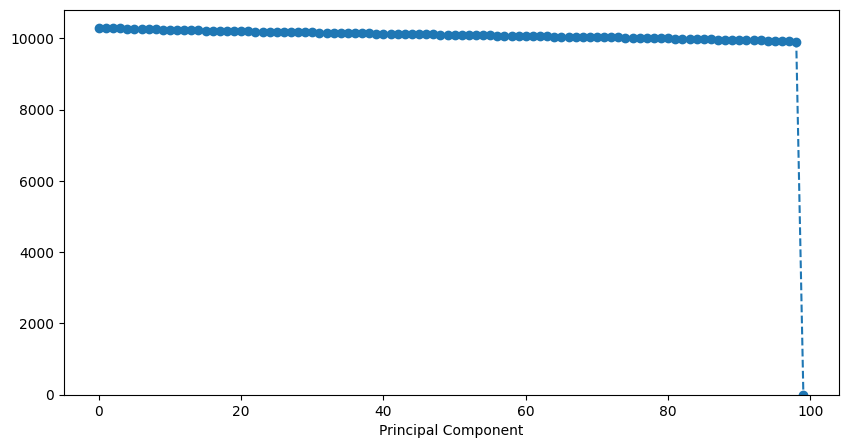

In [ ]:
X = np.random.normal(size=(100, 1000000))

# Show the PCA of the first 20 components
pca = PCA(n_components=100)
pca.fit(X)

# Plot the explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(pca.explained_variance_, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.gca().set_ylim(0)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 100 but size of corresponding boolean axis is 1804

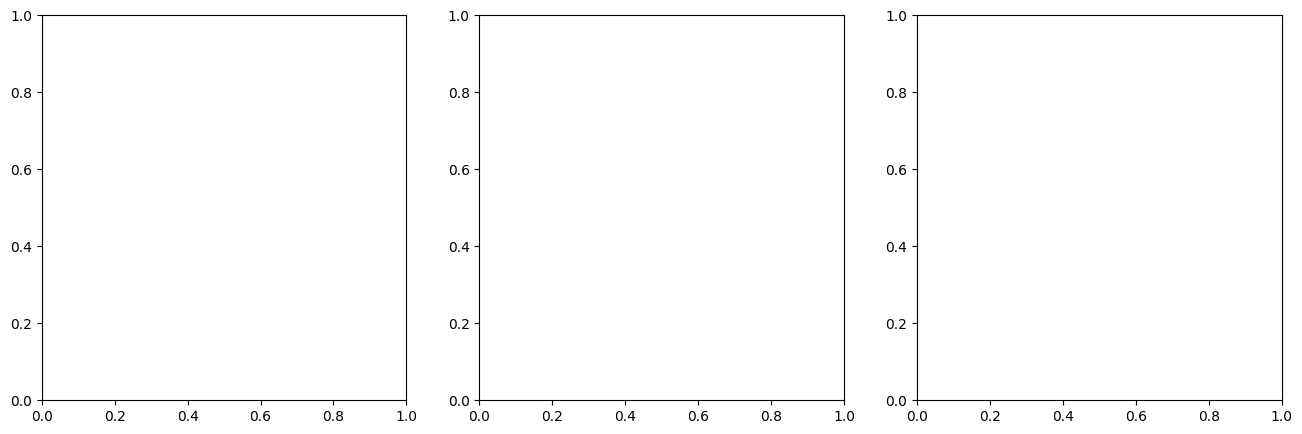

In [ ]:
scaler = StandardScaler().fit(X_train)
pca = PCA(n_components=min(20, X_train.shape[1])).fit(scaler.transform(X_train))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, X, y_enc, title in [
    (axes[0], X_train, y_train_enc, "Train"),
    (axes[1], X_valid, y_valid_enc, "Valid"),
    (axes[2], X_test, y_test_enc, "Test"),
]:
    Z = pca.transform(scaler.transform(X))
    for c, label in enumerate(le.classes_):
        mask = y_enc == c
        ax.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, label=label)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title(title)
    ax.legend(markerscale=3)

fig.suptitle("PCA projection (first 2 components)")
fig.tight_layout()
plt.show()

explained = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(explained)), explained, color="steelblue", alpha=0.7)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title(
    f"Cumulative: {explained[:2].sum():.1%} (PC1+PC2), "
    f"{explained[:5].sum():.1%} (top 5), "
    f"{explained.sum():.1%} (all {len(explained)})"
)
fig.tight_layout()
plt.show()

## Train the model

In [ ]:
clf = LogisticRegression(max_iter=100, class_weight="balanced")
clf.fit(X_train, y_train_enc)

val_acc = accuracy_score(y_valid_enc, clf.predict(X_valid))
test_acc = accuracy_score(y_test_enc, clf.predict(X_test))

print(f"Validation accuracy: {val_acc:.3f}")
print(f"Test accuracy:       {test_acc:.3f}")
print()
print(
    classification_report(
        y_test_enc,
        clf.predict(X_test),
        target_names=le.classes_,
    )
)

Validation accuracy: 0.726
Test accuracy:       0.669

              precision    recall  f1-score   support

         off       0.75      0.71      0.73       708
          on       0.55      0.60      0.58       420

    accuracy                           0.67      1128
   macro avg       0.65      0.66      0.65      1128
weighted avg       0.68      0.67      0.67      1128



/home/mila/s/sobralm/auditorydecoding/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Statistical Test: Is Performance Above Chance?

The test set is unbalanced, so raw accuracy alone is misleading. Two complementary tests are used:

- **Binomial test** (exact): tests whether raw accuracy exceeds the majority-class baseline (the accuracy a trivial "always predict majority" classifier would achieve).
- **Permutation test**: shuffles the test labels 10 000 times and recomputes **balanced accuracy** against the fixed model predictions each time. Balanced accuracy averages per-class recall, so its chance level is always 0.5 regardless of class proportions. The p-value is the fraction of permutations that matched or exceeded the observed balanced accuracy.

Test set class counts  : off=708, on=420
Majority-class chance  : 0.628

Observed accuracy      : 0.669
Observed balanced acc  : 0.656

Binomial test  p-value : 0.001958  (H0: acc ≤ 0.628)
Permutation    p-value : 0  (n=10,000 permutations, balanced acc)


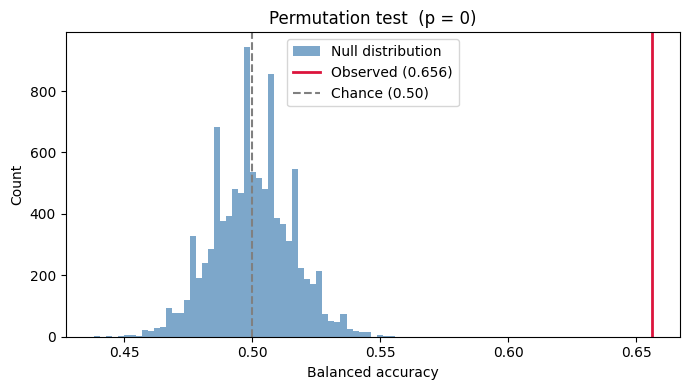

In [ ]:
from scipy.stats import binomtest
from sklearn.metrics import balanced_accuracy_score

N_PERMUTATIONS = 10_000

y_pred_test = clf.predict(X_test)

# Majority-class proportion: the accuracy a trivial classifier achieves on this split
_, counts = np.unique(y_test_enc, return_counts=True)
majority_chance = counts.max() / counts.sum()

n_correct = (y_pred_test == y_test_enc).sum()
n_total = len(y_test_enc)
observed_acc = n_correct / n_total
observed_bal_acc = balanced_accuracy_score(y_test_enc, y_pred_test)

# --- Binomial test (raw accuracy vs. majority-class baseline) ---
binom_result = binomtest(n_correct, n_total, p=majority_chance, alternative="greater")

# --- Permutation test (balanced accuracy; chance = 0.5 by construction) ---
# Shuffling the true labels while keeping predictions fixed builds the null
# distribution under H0: labels are independent of neural activity.
rng = np.random.default_rng(0)
null_bal_accs = np.array([
    balanced_accuracy_score(rng.permutation(y_test_enc), y_pred_test)
    for _ in range(N_PERMUTATIONS)
])
permutation_pvalue = (null_bal_accs >= observed_bal_acc).mean()

class_counts_str = ", ".join(
    f"{le.classes_[c]}={counts[c]}" for c in range(len(le.classes_))
)
print(f"Test set class counts  : {class_counts_str}")
print(f"Majority-class chance  : {majority_chance:.3f}")
print()
print(f"Observed accuracy      : {observed_acc:.3f}")
print(f"Observed balanced acc  : {observed_bal_acc:.3f}")
print()
print(f"Binomial test  p-value : {binom_result.pvalue:.4g}  (H0: acc ≤ {majority_chance:.3f})")
print(f"Permutation    p-value : {permutation_pvalue:.4g}  (n={N_PERMUTATIONS:,} permutations, balanced acc)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_bal_accs, bins=50, color="steelblue", alpha=0.7, label="Null distribution")
ax.axvline(observed_bal_acc, color="crimson", linewidth=2, label=f"Observed ({observed_bal_acc:.3f})")
ax.axvline(0.5, color="gray", linewidth=1.5, linestyle="--", label="Chance (0.50)")
ax.set_xlabel("Balanced accuracy")
ax.set_ylabel("Count")
ax.set_title(f"Permutation test  (p = {permutation_pvalue:.4g})")
ax.legend()
plt.tight_layout()
plt.show()

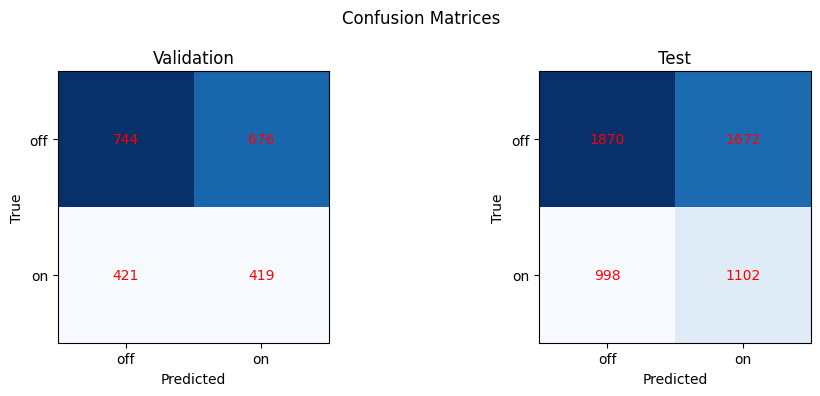

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_valid_enc, clf.predict(X_valid), "Validation"),
    (axes[1], y_test_enc, clf.predict(X_test), "Test"),
]:
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(le.classes_)))
    ax.set_yticks(range(len(le.classes_)))
    ax.set_xticklabels(le.classes_)
    ax.set_yticklabels(le.classes_)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "red" # "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

fig.suptitle("Confusion Matrices")
fig.tight_layout()
plt.show()